Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import sklearn
from sklearn.experimental import enable_iterative_imputer  
from sklearn.linear_model import BayesianRidge
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import chi2
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn import metrics
import pyreadstat
import seaborn as sns
import scipy.stats as stats
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant as ac 
import random
import warnings
warnings.filterwarnings('ignore')

Load Data

In [2]:
df, meta = pyreadstat.read_sav('data.sav')
df.head()

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1.0,526301100.0,20.0,RL,141.0,31770.0,Pave,NA,IR1,Lvl,...,0.0,NA,NA,NA,0.0,5.0,2010.0,WD,Normal,215000.0
1,2.0,526350040.0,20.0,RH,80.0,11622.0,Pave,NA,Reg,Lvl,...,0.0,NA,MnPrv,NA,0.0,6.0,2010.0,WD,Normal,105000.0
2,3.0,526351010.0,20.0,RL,81.0,14267.0,Pave,NA,IR1,Lvl,...,0.0,NA,NA,Gar2,12500.0,6.0,2010.0,WD,Normal,172000.0
3,4.0,526353030.0,20.0,RL,93.0,11160.0,Pave,NA,Reg,Lvl,...,0.0,NA,NA,NA,0.0,4.0,2010.0,WD,Normal,244000.0
4,5.0,527105010.0,60.0,RL,74.0,13830.0,Pave,NA,IR1,Lvl,...,0.0,NA,MnPrv,NA,0.0,3.0,2010.0,WD,Normal,189900.0


Data Label

In [3]:
for col, label in meta.column_names_to_labels.items():
    print(f"{col}: {label}")

Order: Observation number/ID.
PID: Parcel identification number (used for city web site review).
MSSubClass: Type of dwelling involved in the sale (a coded category).
MSZoning: General zoning classification of the sale.
LotFrontage: Linear feet of street connected to property.
LotArea: Lot size in square feet.
Street: Type of road access to property (e.g., Paved, Gravel).
Alley: Type of alley access to property.
LotShape: General shape of property (e.g., Regular, Irregular).
LandContour: Flatness of the property.
Utilities: Type of utilities available.
LotConfig: Lot configuration (e.g., Corner, Inside).
LandSlope: Slope of property (e.g., Gentle, Moderate, Severe).
Neighborhood: Physical locations within Ames city limits.
Condition1: Proximity to main road or railroad.
Condition2: Proximity to a second main road or railroad (if present).
BldgType: Type of dwelling (e.g., Single-family, Duplex).
HouseStyle: Style of dwelling (e.g., 1Story, 2Story, Split Level).
OverallQual: Overall mat

Null Count

In [4]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

LotFrontage     490
MasVnrArea       23
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
GarageYrBlt     159
GarageCars        1
GarageArea        1
dtype: int64


Variables' unique value

In [5]:
unique_values = {col:df[col].unique() 
                 for col in df.select_dtypes(include=['object', 'category']).columns}

for col, values in unique_values.items():
    print(f"Variable: {col}")
    print(f"Values:   {values}")
    print("-" * 30)

Variable: MSZoning
Values:   ['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)']
------------------------------
Variable: Street
Values:   ['Pave' 'Grvl']
------------------------------
Variable: Alley
Values:   ['NA' 'Pave' 'Grvl']
------------------------------
Variable: LotShape
Values:   ['IR1' 'Reg' 'IR2' 'IR3']
------------------------------
Variable: LandContour
Values:   ['Lvl' 'HLS' 'Bnk' 'Low']
------------------------------
Variable: Utilities
Values:   ['AllPub' 'NoSewr' 'NoSeWa']
------------------------------
Variable: LotConfig
Values:   ['Corner' 'Inside' 'CulDSac' 'FR2' 'FR3']
------------------------------
Variable: LandSlope
Values:   ['Gtl' 'Mod' 'Sev']
------------------------------
Variable: Neighborhood
Values:   ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 

number of categorical and numeric data

In [6]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
print(f"Categorical columns detected: {len(cat_cols)}")
print(f"Numerical columns detected: {len(num_cols)}")

Categorical columns detected: 43
Numerical columns detected: 39


ENCODE CATEGORICAL DATA

In [7]:
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value', 
    unknown_value=np.nan
)

df_encoded = df.copy()
if cat_cols:
    df_encoded[cat_cols] = encoder.fit_transform(df[cat_cols])

Mice imputation

In [8]:
mice_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=10),
    max_iter=10,
    random_state=10,
    verbose=1
)

imputed_array = mice_imputer.fit_transform(df_encoded)
df_imputed = pd.DataFrame(imputed_array, columns=df.columns)

[IterativeImputer] Completing matrix with shape (2930, 82)
[IterativeImputer] Change: 764.2917403597341, scaled tolerance: 1007100.11 
[IterativeImputer] Early stopping criterion reached.


In [9]:
if cat_cols:
    df_imputed[cat_cols] = encoder.inverse_transform(df_imputed[cat_cols].round().astype(int))

null count after the imputation   

In [10]:
null_counts = df_imputed.isnull().sum()
print(null_counts[null_counts > 0])   

Series([], dtype: int64)


VIF

In [11]:
X = df_imputed.select_dtypes(include=['number'])
X_with_const = ac(X)     

vif_df = pd.DataFrame()
vif_df["feature"] = X_with_const.columns
vif_df["VIF"] = [vif(X_with_const.values, i) 
                 for i in range(len(X_with_const.columns))]

vif_results = vif_df[vif_df['feature'] != 'const'].sort_values(by="VIF", ascending=False)

print("Global VIF Results for numerical features:")
print(vif_results)

Global VIF Results for numerical features:
          feature           VIF
17   LowQualFinSF           inf
18      GrLivArea           inf
15      @1stFlrSF           inf
16      @2ndFlrSF           inf
11     BsmtFinSF1  5.586814e+04
14    TotalBsmtSF  5.226081e+04
13      BsmtUnfSF  5.198893e+04
12     BsmtFinSF2  7.704249e+03
1           Order  7.930460e+01
38         YrSold  7.724025e+01
39      SalePrice  6.118867e+00
8       YearBuilt  5.864018e+00
29     GarageArea  5.839543e+00
28     GarageCars  5.828526e+00
27    GarageYrBlt  4.624231e+00
25   TotRmsAbvGrd  4.465149e+00
2             PID  3.776358e+00
6     OverallQual  3.773019e+00
21       FullBath  2.813025e+00
9    YearRemodAdd  2.450877e+00
23   BedroomAbvGr  2.395629e+00
22       HalfBath  2.179785e+00
19   BsmtFullBath  2.162602e+00
4     LotFrontage  1.857150e+00
3      MSSubClass  1.726864e+00
24   KitchenAbvGr  1.580021e+00
26     Fireplaces  1.568200e+00
7     OverallCond  1.543243e+00
10     MasVnrArea  1.476725e+

As TotalBsmtSF is sum of BsmtFinSF1, BsmtFinSF2, BsmtUnfSF
and GrLivArea is sum of @1stFlrSF, @2ndFlrSF, LowQualFinSF.


we keep these two variable from the model and drop the sums

In [12]:
cols_to_drop = [ 'Order', 'PID','TotalBsmtSF', 'GrLivArea']
df_reduced = df_imputed.drop(columns=cols_to_drop)

df_numeric_ready = pd.get_dummies(df_reduced, drop_first=True)

df_refined = df_numeric_ready.copy()

VIF After the dropping the variable

In [13]:
X = df_refined.select_dtypes(include=['number'])
X_with_const = ac(X)

vif_df = pd.DataFrame()
vif_df["feature"] = X_with_const.columns
vif_df["VIF"] = [vif(X_with_const.values, i) for i in range(len(X_with_const.columns))]
vif_results = vif_df[vif_df['feature'] != 'const'].sort_values(by="VIF", ascending=False)

print("Global VIF Results for numerical features:")
print(vif_results)

Global VIF Results for numerical features:
          feature       VIF
12      @1stFlrSF  6.202268
13      @2ndFlrSF  6.167740
35      SalePrice  6.099354
25     GarageArea  5.829929
24     GarageCars  5.800649
6       YearBuilt  5.725519
9      BsmtFinSF1  5.138205
23    GarageYrBlt  4.624078
21   TotRmsAbvGrd  4.449851
4     OverallQual  3.750643
11      BsmtUnfSF  3.738121
17       FullBath  2.790113
7    YearRemodAdd  2.418521
19   BedroomAbvGr  2.386757
15   BsmtFullBath  2.157575
18       HalfBath  2.151524
2     LotFrontage  1.846056
1      MSSubClass  1.724583
10     BsmtFinSF2  1.576321
20   KitchenAbvGr  1.575142
22     Fireplaces  1.567622
5     OverallCond  1.535571
8      MasVnrArea  1.461506
3         LotArea  1.352072
28  EnclosedPorch  1.240688
26     WoodDeckSF  1.231701
27    OpenPorchSF  1.223765
16   BsmtHalfBath  1.161418
30    ScreenPorch  1.093500
31       PoolArea  1.091862
14   LowQualFinSF  1.080732
32        MiscVal  1.074862
34         YrSold  1.046593
33   

In [14]:
y = df_refined['SalePrice']
X = df_refined.drop(columns=['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
en_cv = ElasticNetCV(alphas=np.logspace(-4, 4, 50), 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_scaled, y_train)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net1 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net1.fit(X_train_scaled, y_train)

Optimal Alpha: 35.564803062231285
Optimal L1 Ratio: 0.99


ElasticNet(alpha=np.float64(35.564803062231285), l1_ratio=np.float64(0.99))

In [17]:
y_pred = elastic_net1.predict(X_train_scaled)

rmse = np.sqrt(metrics.mean_squared_error(y_train, y_pred))
r2 = r2_score(y_train, y_pred)

n = len(y_train)
p = np.count_nonzero(elastic_net1.coef_)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

rss = np.sum((y_train - y_pred) ** 2)
press_residuals = y_train - cross_val_predict(
    elastic_net1, X_train_scaled, y_train, cv=LeaveOneOut())

press = np.sum(press_residuals ** 2)

print(f"RMSE: {rmse:.4f} | R²: {r2:.4f} | Adj R²: {adj_r2:.4f} | RSS: {rss:.4f} | PRESS: {press:.4f} | p: {p}")

RMSE: 24035.5106 | R²: 0.9066 | Adj R²: 0.8926 | RSS: 1184874533598.3584 | PRESS: 1783220059572.6602 | p: 267


In [18]:
def plot_regression_diagnostics(y_true, y_pred, X_scaled):
    residuals = y_true - y_pred
    
    n = len(y_true)
    p = X_scaled.shape[1]
    mse = np.mean(residuals**2)
    leverage = (1/n) + (X_scaled**2).sum(axis=1) / ((X_scaled**2).sum())
    cooks_d = (residuals**2 / (p * mse)) * (leverage / (1 - leverage)**2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    plt.subplots_adjust(hspace=0.3)

    sns.regplot(x=y_true, y=y_pred, ax=axes[0, 0], 
                scatter_kws={'alpha':0.5}, 
                line_kws={'color':'red'})
    
    axes[0, 0].set_title('Predicted vs. Actual Sales Price')
    axes[0, 0].set_xlabel('Actual Price')
    axes[0, 0].set_ylabel('Predicted Price')

    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Normal Q-Q Plot')

    sns.residplot(x=y_pred, y=residuals, 
                  lowess=True, 
                  ax=axes[1, 0], 
                  scatter_kws={'alpha':0.5}, 
                  line_kws={'color':'red'})
    
    axes[1, 0].set_title('Residuals vs. Fitted')
    axes[1, 0].set_xlabel('Predicted Sales Price')
    axes[1, 0].set_ylabel('Residuals')
    axes[1, 0].axhline(0, color='black', linestyle='--')

    axes[1, 1].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
    axes[1, 1].set_title("Cook's Distance")
    axes[1, 1].set_xlabel('Observation Index')
    axes[1, 1].set_ylabel('Distance')
    axes[1, 1].axhline(4/n, color='red', linestyle='--', label='Threshold (4/n)')
    axes[1, 1].legend()

    plt.show()

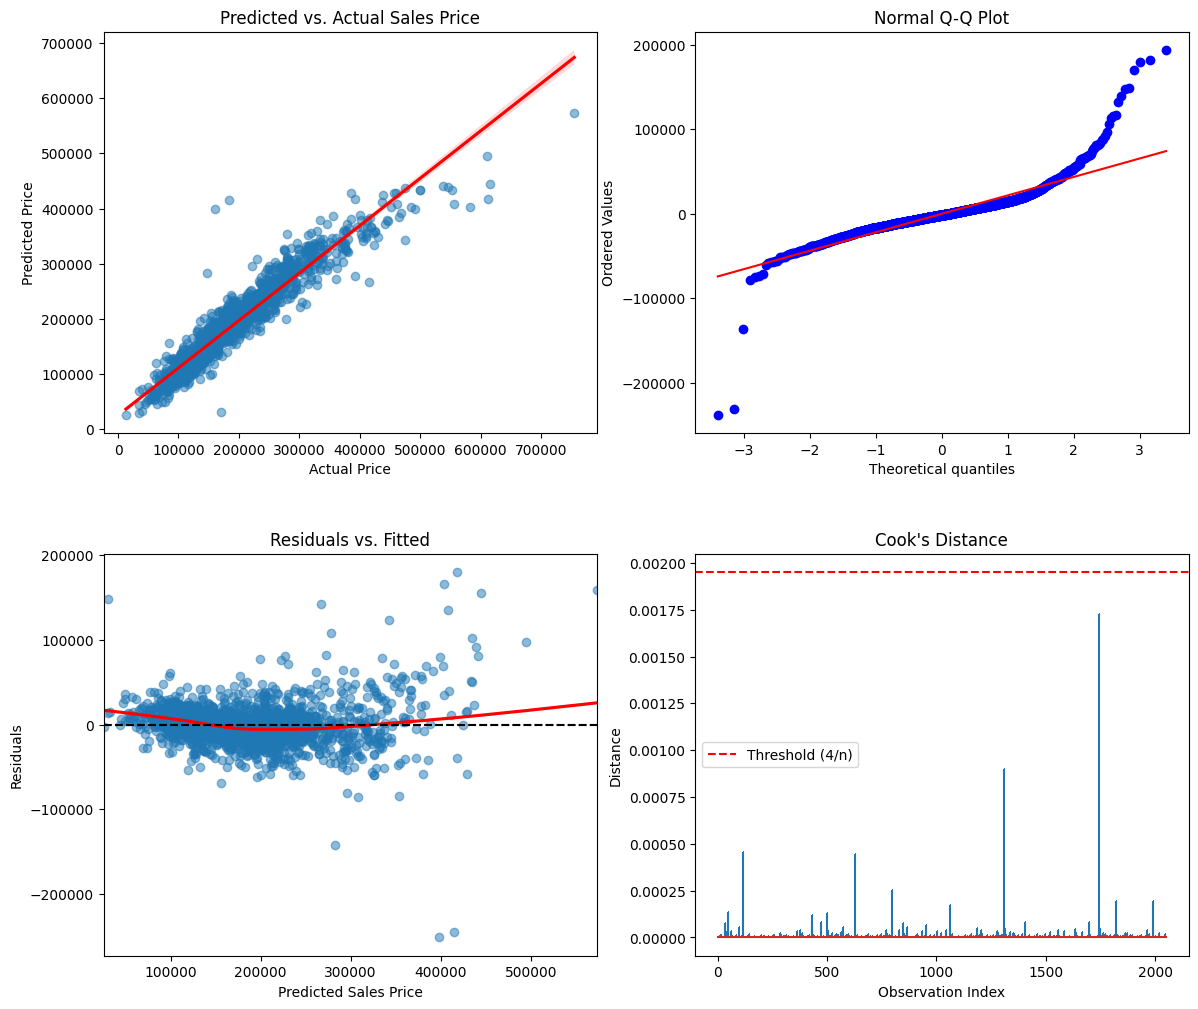

In [19]:
y_train_pred = elastic_net1.predict(X_train_scaled)

plot_regression_diagnostics(y_train, y_train_pred, X_train_scaled)

Variance Check

In [20]:
variances = df_refined.var()
variance_df = pd.DataFrame(variances, columns=['Variance'])
variance_df = variance_df.sort_values(by='Variance', ascending=True)

print("--- Variables with the Lowest Variance ---")
print(variance_df.head(20))

threshold = 0.001
low_variance_cols = variance_df[variance_df['Variance'] < threshold].index.tolist()

print(f"\nColumns with variance below {threshold}:")
print(low_variance_cols)

--- Variables with the Lowest Variance ---
                      Variance
RoofMatl_Roll         0.000341
SaleType_VWD          0.000341
Exterior2nd_Other     0.000341
Neighborhood_Landmrk  0.000341
MiscFeature_TenC      0.000341
Condition2_RRAn       0.000341
Utilities_NoSeWa      0.000341
Electrical_Mix        0.000341
RoofMatl_Metal        0.000341
Condition2_RRAe       0.000341
RoofMatl_Membran      0.000341
Exterior1st_ImStucc   0.000341
MasVnrType_CBlock     0.000341
Exterior2nd_PreCast   0.000341
Exterior1st_PreCast   0.000341
KitchenQual_Po        0.000341
Condition2_RRNn       0.000682
PoolQC_Fa             0.000682
Neighborhood_GrnHill  0.000682
Heating_OthW          0.000682

Columns with variance below 0.001:
['RoofMatl_Roll', 'SaleType_VWD', 'Exterior2nd_Other', 'Neighborhood_Landmrk', 'MiscFeature_TenC', 'Condition2_RRAn', 'Utilities_NoSeWa', 'Electrical_Mix', 'RoofMatl_Metal', 'Condition2_RRAe', 'RoofMatl_Membran', 'Exterior1st_ImStucc', 'MasVnrType_CBlock', 'Exterior2nd_

Correaltion Check

In [21]:
vars_to_check = [col for col in df_refined if col not in cols_to_drop]

specific_correlations = df_refined[vars_to_check].corr()[['SalePrice']]

correlations_threshold = 0.001
low_corr_cols = specific_correlations[abs(specific_correlations['SalePrice']) < correlations_threshold]

print("Correlation with SalePrice:")
print(specific_correlations.drop('SalePrice'))
print(f"\nColumns with low correlation to SalePrice (Abs Corr < {correlations_threshold}):")
print(low_corr_cols)

Correlation with SalePrice:
                       SalePrice
MSSubClass             -0.085092
LotFrontage             0.351349
LotArea                 0.266549
OverallQual             0.799262
OverallCond            -0.101697
...                          ...
SaleCondition_AdjLand  -0.057710
SaleCondition_Alloca   -0.021564
SaleCondition_Family   -0.036853
SaleCondition_Normal   -0.141418
SaleCondition_Partial   0.350122

[283 rows x 1 columns]

Columns with low correlation to SalePrice (Abs Corr < 0.001):
                 SalePrice
RoofMatl_Metal   -0.000184
Foundation_Wood   0.000054
SaleType_ConLI   -0.000480


In [22]:
cols_to_remove = set(low_variance_cols) | set(low_corr_cols.index)
print(f"\nTotal columns to remove (low variance or low correlation): {len(cols_to_remove)}")


Total columns to remove (low variance or low correlation): 30


In [23]:
df_cleaned = df_refined.drop(columns=cols_to_remove)

permorfing elastic net after removing those variables

In [24]:
y = df_refined['SalePrice']
X = df_refined.drop(columns=['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
en_cv = ElasticNetCV(alphas=np.logspace(-4, 4, 50), 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_scaled, y_train)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net2 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net2.fit(X_train_scaled, y_train)

Optimal Alpha: 35.564803062231285
Optimal L1 Ratio: 0.99


ElasticNet(alpha=np.float64(35.564803062231285), l1_ratio=np.float64(0.99))

In [26]:
y_pred = elastic_net2.predict(X_train_scaled)

rmse = np.sqrt(metrics.mean_squared_error(y_train, y_pred))
r2 = r2_score(y_train, y_pred)

n = len(y_train)
p = np.count_nonzero(elastic_net2.coef_)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

rss = np.sum((y_train - y_pred) ** 2)
press_residuals = y_train - cross_val_predict(
    elastic_net2, X_train_scaled, y_train, cv=LeaveOneOut())

press = np.sum(press_residuals ** 2)

print(f"RMSE: {rmse:.4f} | R²: {r2:.4f} | Adj R²: {adj_r2:.4f} | RSS: {rss:.4f} | PRESS: {press:.4f} | p: {p}")

RMSE: 24035.5106 | R²: 0.9066 | Adj R²: 0.8926 | RSS: 1184874533598.3584 | PRESS: 1783220059572.6602 | p: 267


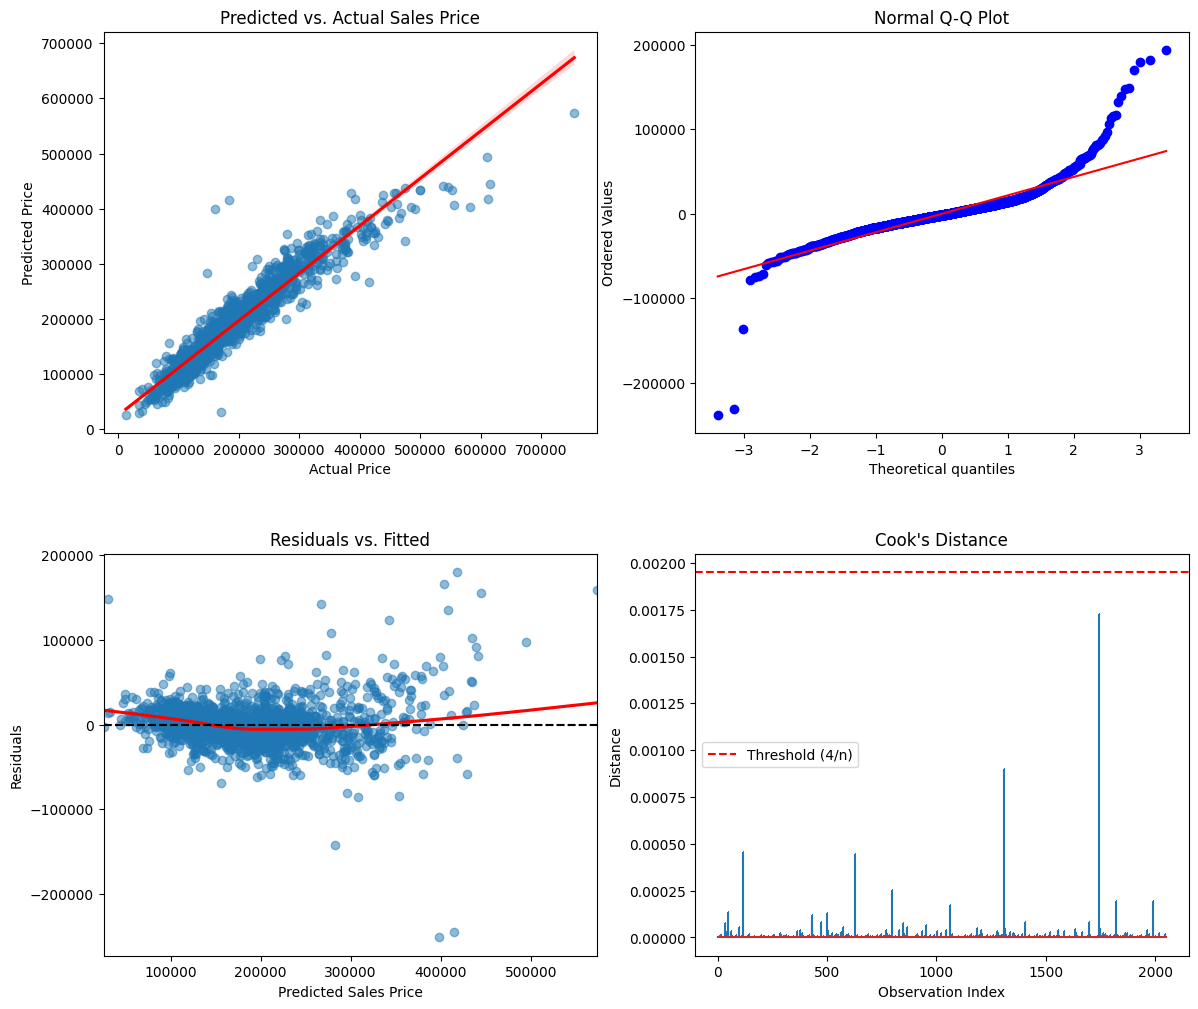

In [27]:
y_train_pred = elastic_net2.predict(X_train_scaled)

plot_regression_diagnostics(y_train, y_train_pred, X_train_scaled)

skewness check

In [28]:
skewness_y = stats.skew(y_train)
print(f"Skewness of SalePrice: {skewness_y:.4f}")

Skewness of SalePrice: 1.7088


In [29]:
skewness_x = stats.skew(X_train_scaled, axis=0)
print(f"Skewness of features (first 10): {skewness_x[:10]}")

highly_skewed_features = np.where(abs(skewness_x) > 1)[0]
print(f"Number of highly skewed features: {len(highly_skewed_features)}")

Skewness of features (first 10): [ 1.35384271  1.62484806 13.29985414  0.20835408  0.63440173 -0.57350187
 -0.44924649  2.60306634  1.65970753  4.0438261 ]
Number of highly skewed features: 236


apply box cox transformation 

In [30]:
y_train_boxcox, fitted_lambda = boxcox(y_train)
print(f"Optimal Box-Cox Lambda: {fitted_lambda:.4f}")

Optimal Box-Cox Lambda: -0.0144


In [31]:
pt = PowerTransformer(method='yeo-johnson')
X_train_transformed = pt.fit_transform(X_train)

In [32]:
X_train_transformed_scaled = scaler.fit_transform(X_train_transformed)

elastic net perform 

In [33]:
en_cv = ElasticNetCV(alphas=np.logspace(-4, 4, 50), 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_transformed_scaled, y_train_boxcox)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net3 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net3.fit(X_train_transformed_scaled, y_train_boxcox)

Optimal Alpha: 0.02811768697974228
Optimal L1 Ratio: 0.1


ElasticNet(alpha=np.float64(0.02811768697974228), l1_ratio=np.float64(0.1))

In [34]:
y_pred_boxcox = elastic_net3.predict(X_train_transformed_scaled)
y_pred_original = inv_boxcox(y_pred_boxcox, fitted_lambda)

In [35]:
rmse = np.sqrt(metrics.mean_squared_error(y_train, y_pred_original))
r2 = r2_score(y_train, y_pred_original)

n = len(y_train)
p = np.count_nonzero(elastic_net3.coef_)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

rss = np.sum((y_train - y_pred_original) ** 2)

cv_preds_boxcox = cross_val_predict(
    elastic_net3, X_train_transformed, y_train_boxcox, cv=LeaveOneOut()
    )
cv_preds_original = inv_boxcox(cv_preds_boxcox, fitted_lambda)

press_residuals = y_train - cv_preds_original
press = np.sum(press_residuals ** 2)

print(f"RMSE: {rmse:.4f} | R²: {r2:.4f} | Adj R²: {adj_r2:.4f} | RSS: {rss:.4f} | PRESS: {press:.4f} | p: {p}")

RMSE: 23036.0349 | R²: 0.9142 | Adj R²: 0.9088 | RSS: 1088381411339.1481 | PRESS: 1567876518578.5957 | p: 122


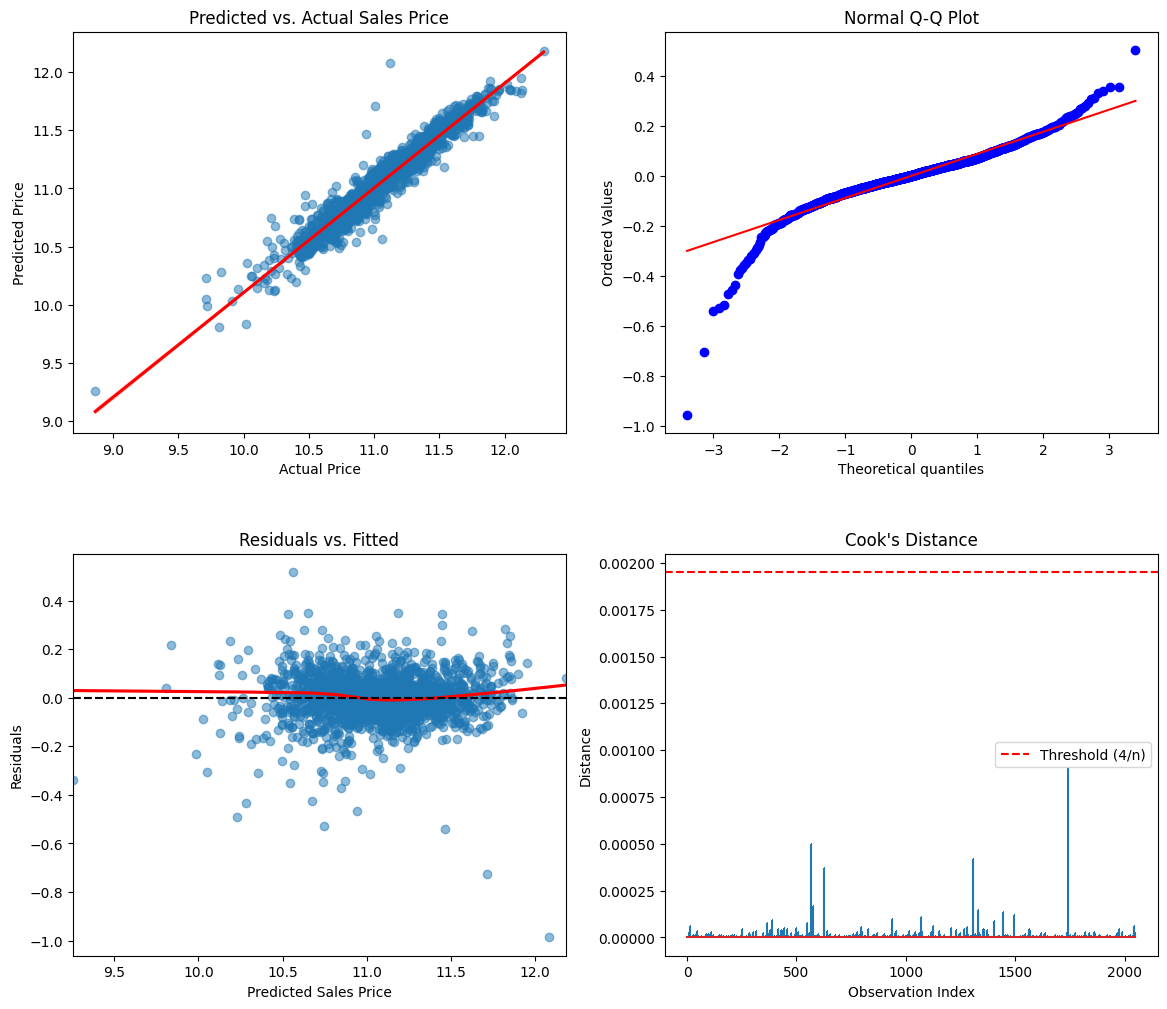

In [36]:
plot_regression_diagnostics(y_train_boxcox, y_pred_boxcox, X_train_transformed)

Dealing with outliers

Creator of the AMES housing data set Dean De Cock suggests to drop observation of gross living area > 4000

In [48]:
df_cleaned2 = df_imputed.copy()
df_cleaned2 = df_cleaned2[df_cleaned2['GrLivArea'] <= 4000]
print(len(df_imputed[df_imputed['GrLivArea'] > 4000]))

5


In [49]:
df_cleaned2 = pd.get_dummies(df_cleaned2, drop_first=True)
df_cleaned2 = df_cleaned2.drop(columns=cols_to_drop)
df_cleaned2 = df_cleaned2.drop(columns=cols_to_remove)

In [50]:
y = df_cleaned2['SalePrice']
X = df_cleaned2.drop(columns=['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

In [51]:
y_train_boxcox, fitted_lambda = boxcox(y_train)
print(f"Optimal Box-Cox Lambda: {fitted_lambda:.4f}")

Optimal Box-Cox Lambda: -0.0350


In [52]:
pt = PowerTransformer(method='yeo-johnson')
X_train_transformed = pt.fit_transform(X_train)

In [53]:
X_train_transformed_scaled = scaler.fit_transform(X_train_transformed)

In [54]:
en_cv = ElasticNetCV(alphas=np.logspace(-4, 4, 50), 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_transformed_scaled, y_train_boxcox)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net3 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net3.fit(X_train_transformed_scaled, y_train_boxcox)

Optimal Alpha: 0.02811768697974228
Optimal L1 Ratio: 0.1


ElasticNet(alpha=np.float64(0.02811768697974228), l1_ratio=np.float64(0.1))

In [55]:
y_pred_boxcox = elastic_net3.predict(X_train_transformed_scaled)
y_pred_original = inv_boxcox(y_pred_boxcox, fitted_lambda)

In [56]:
rmse = np.sqrt(metrics.mean_squared_error(y_train, y_pred_original))
r2 = r2_score(y_train, y_pred_original)

n = len(y_train)
p = np.count_nonzero(elastic_net3.coef_)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

rss = np.sum((y_train - y_pred_original) ** 2)

cv_preds_boxcox = cross_val_predict(
    elastic_net3, X_train_transformed, y_train_boxcox, cv=LeaveOneOut()
    )
cv_preds_original = inv_boxcox(cv_preds_boxcox, fitted_lambda)

press_residuals = y_train - cv_preds_original
press = np.sum(press_residuals ** 2)

print(f"RMSE: {rmse:.4f} | R²: {r2:.4f} | Adj R²: {adj_r2:.4f} | RSS: {rss:.4f} | PRESS: {press:.4f} | p: {p}")

RMSE: 20571.7046 | R²: 0.9342 | Adj R²: 0.9309 | RSS: 866280224440.2852 | PRESS: 997562779471.3317 | p: 99


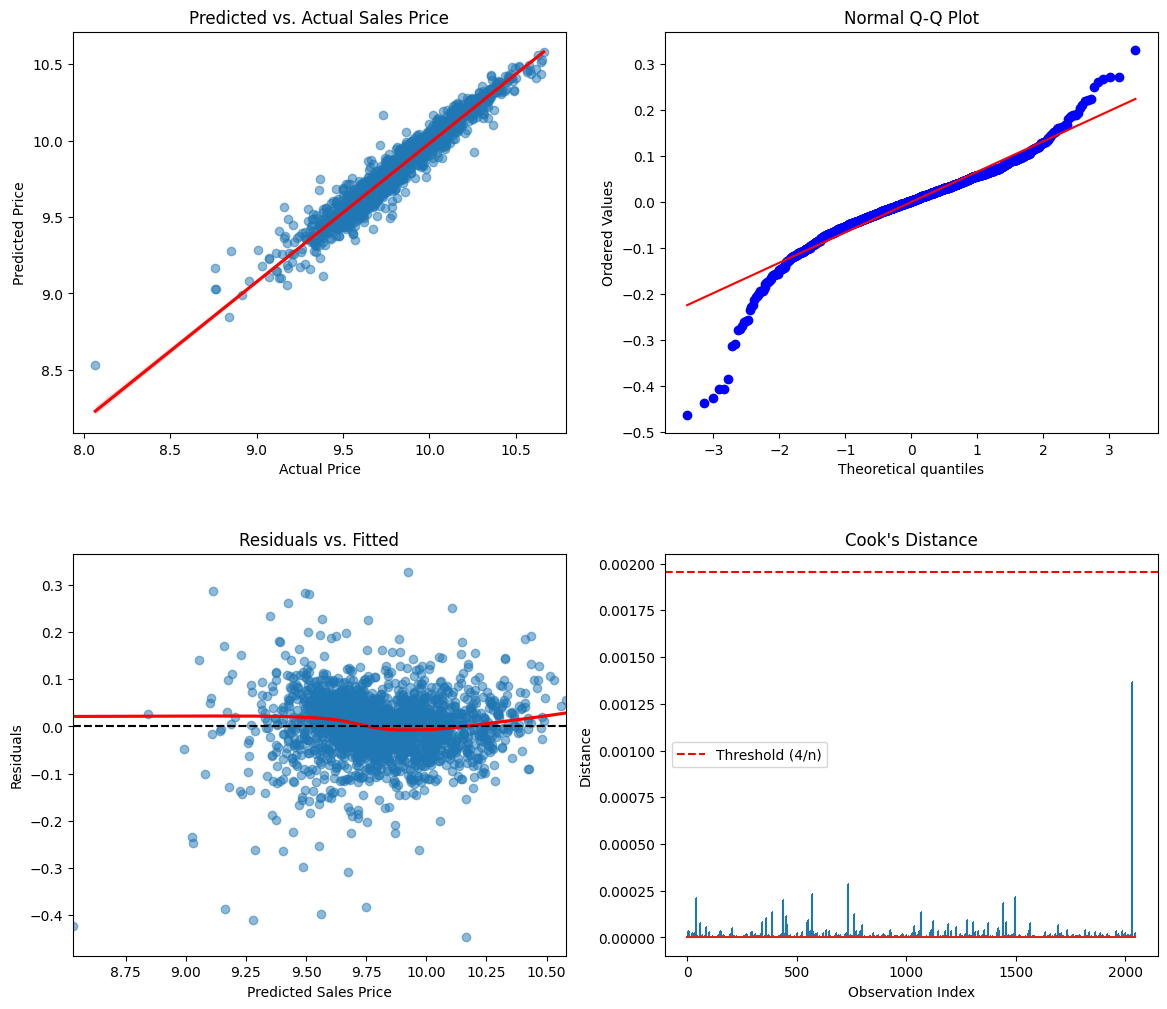

In [ ]:
plot_regression_diagnostics(y_train_boxcox, y_pred_boxcox, X_train_transformed)

on test data

In [ ]:
y_test_boccox = boxcox(y_test, lmbda=fitted_lambda)
X_test_transformed = pt.transform(X_test)
X_test_scaled = scaler.transform(X_test_transformed)

In [ ]:
y_test_pred_boxcox = elastic_net3.predict(X_test_scaled)
y_pred_original = inv_boxcox(y_test_pred_boxcox, fitted_lambda)

In [ ]:
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred_original))
r2 = r2_score(y_test, y_pred_original)


rss = np.sum((y_test - y_pred_original) ** 2)
print(f"RMSE: {rmse:.4f} | R²: {r2:.4f} | Adj R²: {adj_r2:.4f} | RSS: {rss:.4f} ")

RMSE: 20415.7538 | R²: 0.9249 | Adj R²: 0.9357 | RSS: 365953035741.1375 


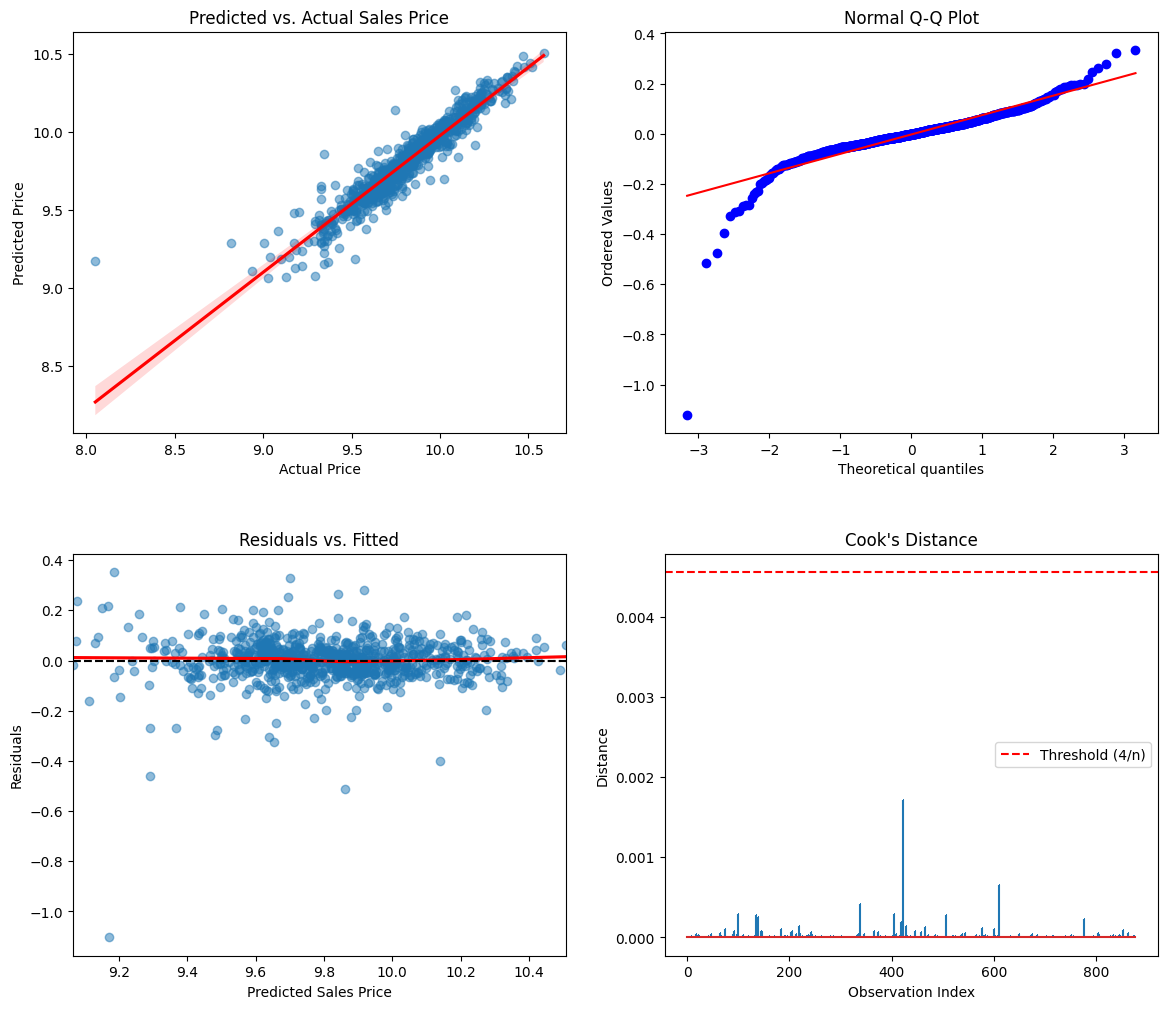

In [ ]:
plot_regression_diagnostics(y_test_boccox, y_test_pred_boxcox, X_test_transformed)

adjusting some variables

In [ ]:

""" age_at_sale = df_cleaned2['YrSold'] - df_cleaned2['YearBuilt']

tol_bath = (df_cleaned2['FullBath'] + 0.5 * df_cleaned2['HalfBath'] + 
            df_cleaned2['BsmtFullBath'] + 0.5 * df_cleaned2['BsmtHalfBath'])

df_cleaned3 = df_cleaned2.copy()

# df_cleaned3['TotalUsableSF'] = tusf
df_cleaned3['AgeAtSale'] = age_at_sale
df_cleaned3['TotalBath'] = tol_bath

df_cleaned3 = df_cleaned3.drop(columns=['YrSold', 'YearBuilt', 
                                        'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath'])"""


In [ ]:
""" y = df_cleaned3['SalePrice']
X = df_cleaned3.drop(columns=['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10) """

log transform in y

In [ ]:
y_train_log = np.log1p(y_train)

In [ ]:
en_cv = ElasticNetCV(alphas=np.logspace(-4, 4, 50), 
                     l1_ratio=[.1, .5, .7, .9, .95, .99, 1], 
                     cv=5)
en_cv.fit(X_train_transformed_scaled, y_train_log)

print(f"Optimal Alpha: {en_cv.alpha_}")
print(f"Optimal L1 Ratio: {en_cv.l1_ratio_}")

elastic_net3 = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_)
elastic_net3.fit(X_train_transformed_scaled, y_train_log)

Optimal Alpha: 0.040949150623804234
Optimal L1 Ratio: 0.1


ElasticNet(alpha=np.float64(0.040949150623804234), l1_ratio=np.float64(0.1))

In [ ]:
y_pred_log = elastic_net3.predict(X_train_transformed_scaled)
y_pred_original = np.expm1(y_pred_log)

In [ ]:
rmse = np.sqrt(metrics.mean_squared_error(y_train, y_pred_original))
r2 = r2_score(y_train, y_pred_original)

n = len(y_train)
p = np.count_nonzero(elastic_net3.coef_)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

rss = np.sum((y_train - y_pred_original) ** 2)

cv_preds_boxcox = cross_val_predict(
    elastic_net3, X_train_transformed, y_train_boxcox, cv=LeaveOneOut()
    )
cv_preds_original = inv_boxcox(cv_preds_boxcox, fitted_lambda)

press_residuals = y_train - cv_preds_original
press = np.sum(press_residuals ** 2)

print(f"RMSE: {rmse:.4f} | R²: {r2:.4f} | Adj R²: {adj_r2:.4f} | RSS: {rss:.4f} | PRESS: {press:.4f} | p: {p}")

RMSE: 19972.0072 | R²: 0.9380 | Adj R²: 0.9350 | RSS: 816509553840.5709 | PRESS: 983388301032.1866 | p: 93


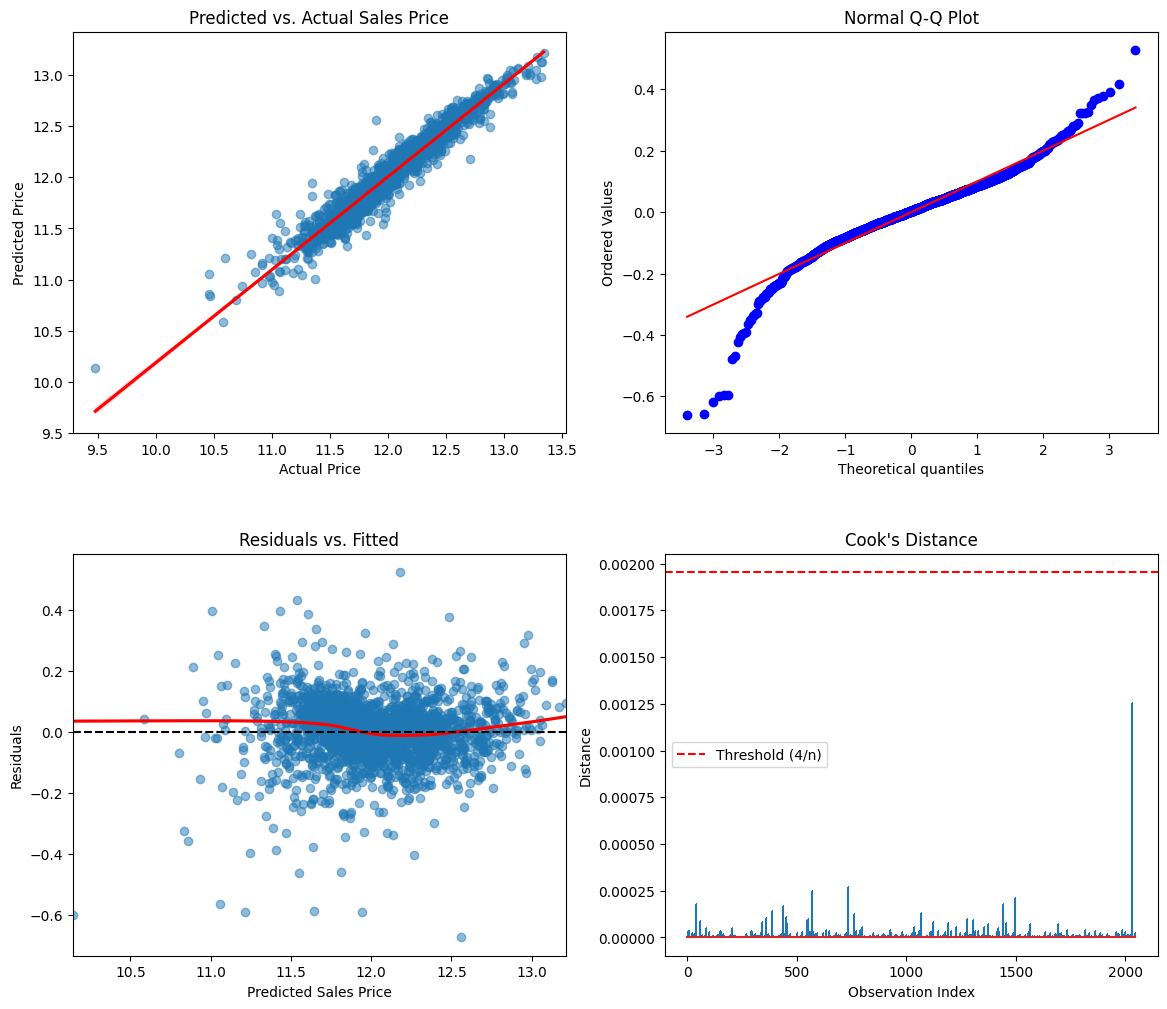

In [ ]:
plot_regression_diagnostics(y_train_log, y_pred_log, X_train_transformed)

on test data

In [ ]:
y_test_log = np.log1p(y_test)
X_test_transformed = pt.transform(X_test)
X_test_scaled = scaler.transform(X_test_transformed)

In [ ]:
y_test_pred_log = elastic_net3.predict(X_test_scaled)
y_test_pred_original = np.expm1(y_test_pred_log)

In [ ]:
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_original))
r2 = r2_score(y_test, y_test_pred_original)

rss = np.sum((y_test - y_test_pred_original) ** 2)


print(f"RMSE: {rmse:.4f} | R²: {r2:.4f} | Adj R²: {adj_r2:.4f} | RSS: {rss:.4f} ")

RMSE: 20581.9618 | R²: 0.9237 | Adj R²: 0.9350 | RSS: 371935858220.3792 


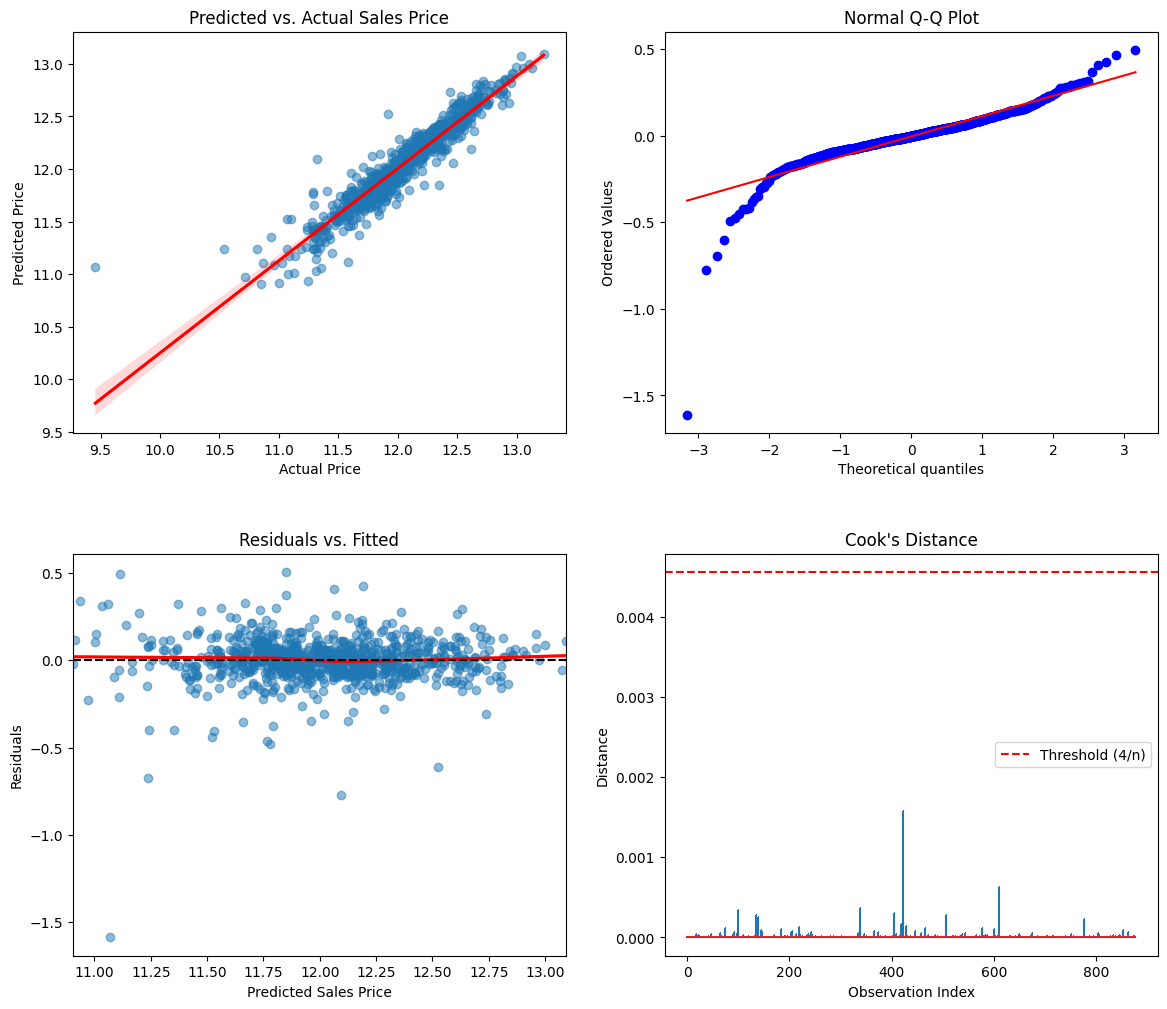

In [ ]:
plot_regression_diagnostics(y_test_log, y_test_pred_log, X_test_transformed)